<a href="https://colab.research.google.com/github/bhanu151/statistical-learning-course-2026/blob/main/CSSL_06_polynomial_regression_bias_variance_tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial regression
Let's try loading a dataset from Kaggle. To do this, you will need to [create a legacy API key from Kaggle](https://www.kaggle.com/settings). This will download a kaggle.json file. If you have previously downloaded the kaggle.json file, you can continue to use the same one.

In [ ]:
from google.colab import files
files.upload()

**Note**-For the below step, the downloaded json files name should match. Please ensure that the file name is kaggle.json

In [3]:
# Change the permissions of the kaggle.json file such that only you can read/write the file.
# This is to prevent someone else from modifying the file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!pip install -q kaggle # Install that Kaggle package to interact with Kaggle's datasets; pip is python's package manager

In [5]:
!kaggle datasets download -d mirajdeepbhandari/polynomial-regression

Dataset URL: https://www.kaggle.com/datasets/mirajdeepbhandari/polynomial-regression
License(s): CC0-1.0
  0% 0.00/1.18k [00:00<?, ?B/s]
100% 1.18k/1.18k [00:00<00:00, 3.65MB/s]


In [6]:
!unzip polynomial-regression.zip

Archive:  polynomial-regression.zip
  inflating: Ice_cream selling data.csv  


In [7]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import scale, PolynomialFeatures
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.metrics import PredictionErrorDisplay

In [8]:
os.listdir() # Look for the files/directories within the current directory

['.config',
 'kaggle.json',
 'Ice_cream selling data.csv',
 'polynomial-regression.zip',
 'sample_data']

The Ice_cream selling data.csv is available!

In [9]:
data = pd.read_csv("Ice_cream selling data.csv") # Read the csv file into a pandas dataframe
type(data)

pandas.core.frame.DataFrame

In [10]:
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [11]:
data.shape

(49, 2)

In [12]:
data.info() # Gives basic information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [13]:
data.describe() # Gives basic statistics about the columns of the dataframe

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [14]:
X = data.iloc[:, :-1] # Extract feaures into X
y = data.iloc[:, -1] # Extract the dependent variable in to y

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) # Split the dataset into train and test sets
model = LinearRegression() # Linear regression model applies here as well because the equation is still linear in X
model.fit(X_train, y_train)
r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)
print(f"r2 train ={r2_train}, r2_test={r2_test}")
print(model.coef_, model.intercept_)


r2 train =0.02937510720510217, r2_test=-0.03912798782600069
[-0.76405794] 16.962431949649158


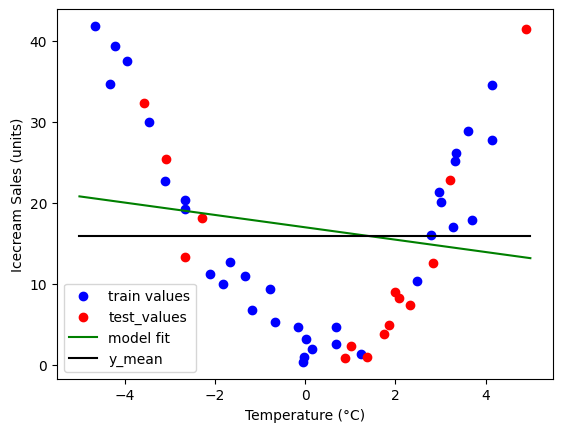

In [16]:
plt.figure()
plt.scatter(X_train, y_train, c="b", label="train values")
plt.scatter(X_test, y_test, c="r", label="test_values")
x_values = np.arange(-5,5,0.01)
y_values = model.coef_[0]*x_values + model.intercept_
plt.plot(x_values, y_values, "g", label="model fit")
plt.plot(x_values, [np.mean(y)]*len(x_values), c="k", label="y_mean")
plt.xlabel("Temperature (°C)")
plt.ylabel("Icecream Sales (units)")
plt.legend()

Clearly the linear model is doing a very bad job at capturing the pattern in the data. Let's try fitting a quadratic model.

In [17]:
# Let's add polynomial features of degree 2 to X

poly_features= PolynomialFeatures(degree=2)
X_transformed = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3, random_state=0)

# Fit using Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_error = mean_squared_error(y_train, y_pred_train)
test_error = mean_squared_error(y_test, y_pred_test)

print(r2_train, r2_test)
print(train_error, test_error)

0.933109383805153 0.9112396415848207
9.861627186505526 12.351860655176438


The $R^2$ values are much higher. The quadratic model with degree 2 is doing a better job than the linear model.

## Fitting polynomials of different degrees
Let's try fitting polynomials of degrees 1 to 9 to see how these models perform on the data

degree = 1, train_r2_score = 0.02937510720510217, test_r2_score = -0.03912798782600069 
		 train_error=143.09841013876851, test_error=144.60468995048183


degree = 2, train_r2_score = 0.933109383805153, test_r2_score = 0.9112396415848207 
		 train_error=9.861627186505526, test_error=12.351860655176438


degree = 3, train_r2_score = 0.9367314665773038, test_r2_score = 0.9239134911292493 
		 train_error=9.32762657521549, test_error=10.588172153545953


degree = 4, train_r2_score = 0.9429293313892029, test_r2_score = 0.9242090261272523 
		 train_error=8.413880588046377, test_error=10.547045605847865


degree = 5, train_r2_score = 0.9435491154163755, test_r2_score = 0.9179152223479036 
		 train_error=8.322506351123161, test_error=11.422889154269622


degree = 6, train_r2_score = 0.945934302821902, test_r2_score = 0.7749158274123696 
		 train_error=7.97086018158074, test_error=31.322635297207633


degree = 7, train_r2_score = 0.9476294730271688, test_r2_score = 0.9514488267925614 
		 train_

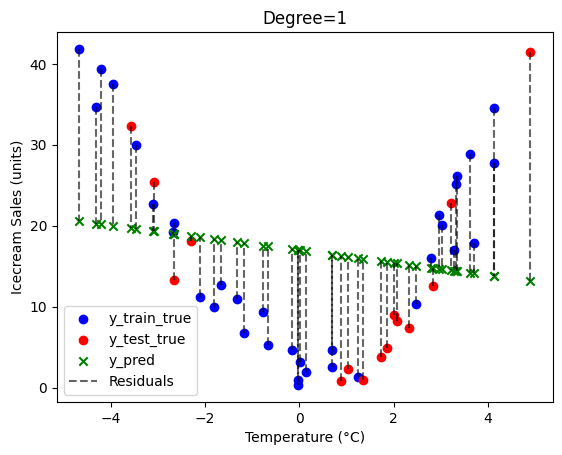

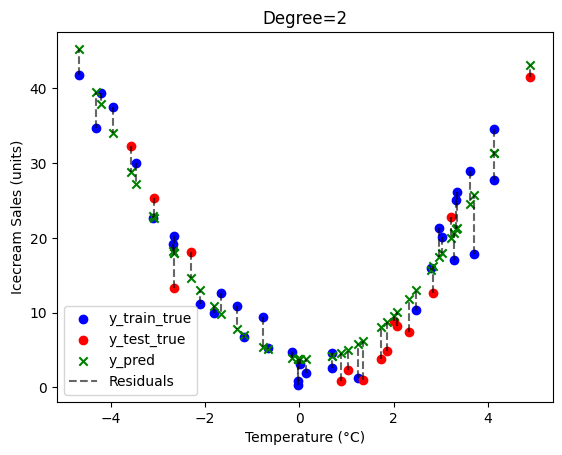

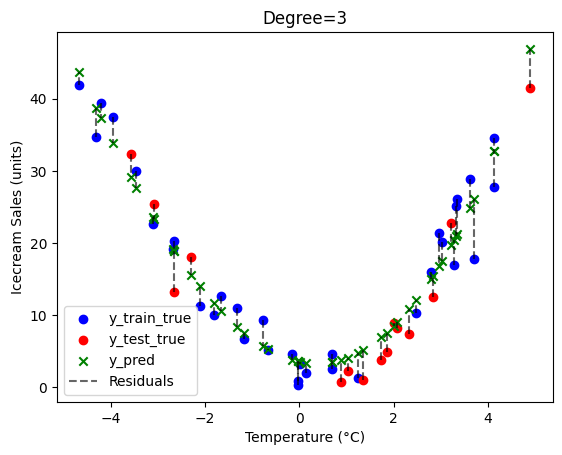

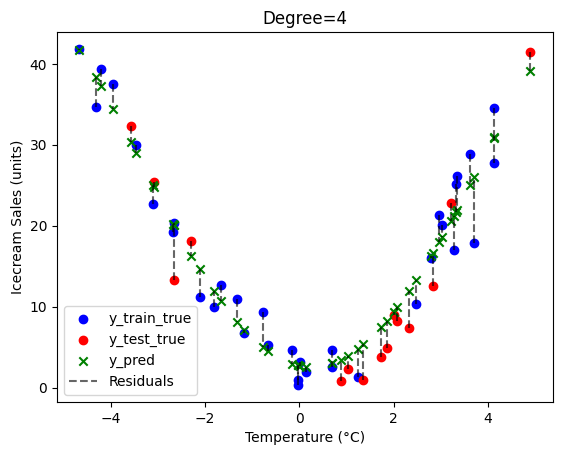

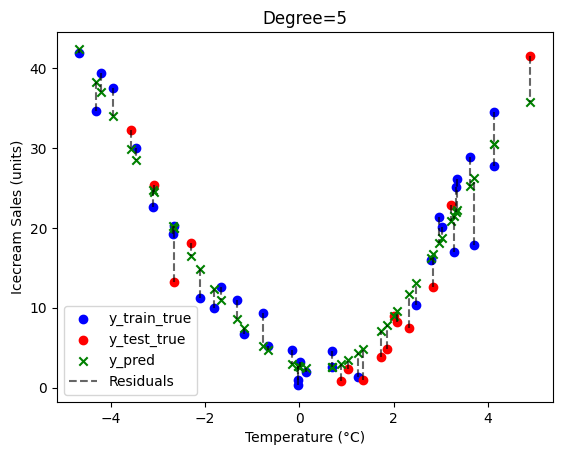

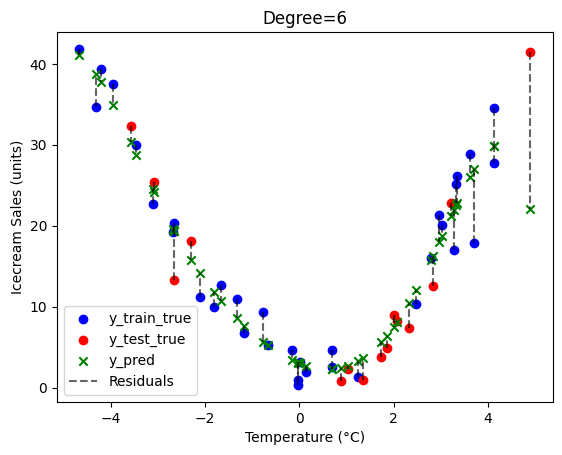

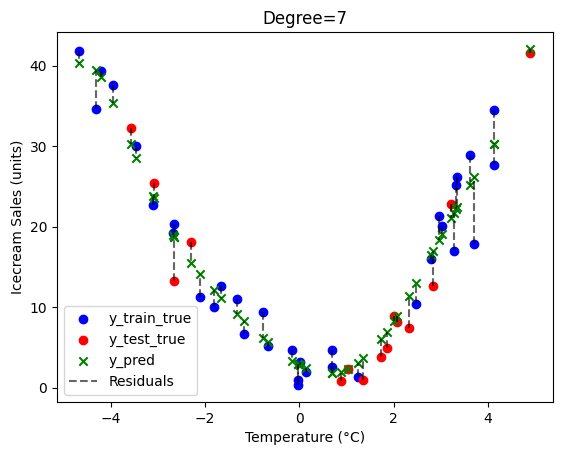

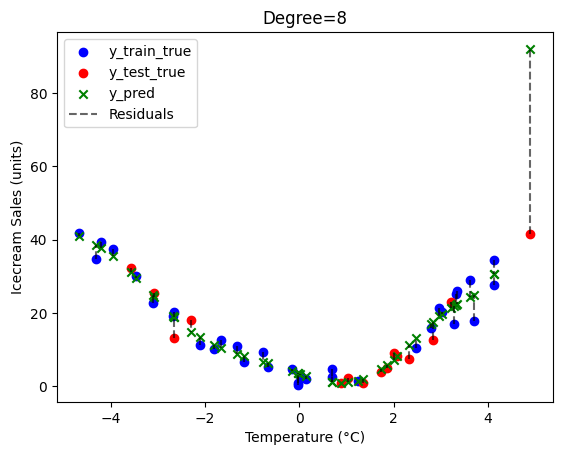

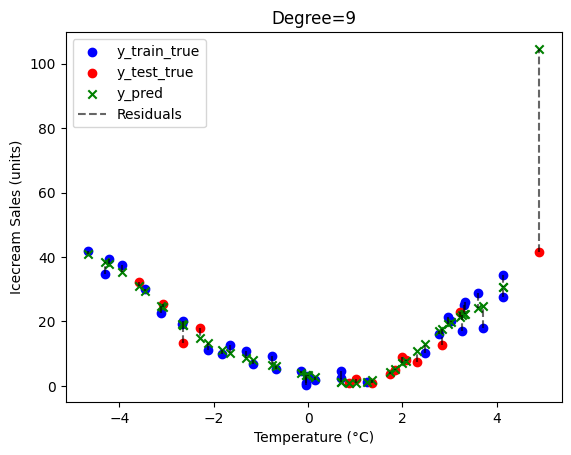

In [22]:
degrees = range(1,10)
train_errors = []
test_errors = []
for degree in degrees:
  if degree>1: # We need to include polynomial features only for models with degree above 1
    poly_features = PolynomialFeatures(degree=degree)
    X_transformed = poly_features.fit_transform(X)

  else: # The features remain as is for the linear model. We are just converting it to a numpy array for consistency since poly_features.fit_transform returns a numpy ndarray.
    # We need to add a column of ones as scaling factors for the intercept parameter, so that the values of Temeperature always appear as the second column following the ones.
    # This step ensures that the parameter corresponding to the second column will always be the linear term in all models we are building. It helps if we want to compare the parameters across models.
    ones_col = np.ones((len(X), 1))
    X_transformed = np.hstack((ones_col, X.to_numpy()))

  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3, random_state=0)

  model = LinearRegression()
  model.fit(X_train,y_train)
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  y_pred_all = model.predict(X_transformed)
  train_error = mean_squared_error(y_train, y_pred_train)
  train_errors.append(train_error)
  test_error = mean_squared_error(y_test, y_pred_test)
  test_errors.append(test_error)
  print(f"degree = {degree}, train_r2_score = {r2_score(y_train, y_pred_train)}, test_r2_score = {r2_score(y_test, y_pred_test)} \n\t\t train_error={train_error}, test_error={test_error}\n\n")
  plt.figure()
  plt.scatter(X_train[:, 1], y_train[:], color="b", label="y_train_true")
  plt.scatter(X_test[:, 1], y_test[:], color="r", label="y_test_true")
  plt.scatter(X, y_pred_all, color="g", marker="x", label="y_pred")
  plt.vlines(X, y, y_pred_all, color='k', linestyle='--', alpha=0.6, label='Residuals')
  plt.title(f"Degree={degree}")
  plt.xlabel("Temperature (°C)")
  plt.ylabel("Icecream Sales (units)")
  plt.legend()
  # print(train_errors, test_errors)
  # print(r2_score(y_test, y_pred_test))


Now let's plot the train and test errors as a function of degrees

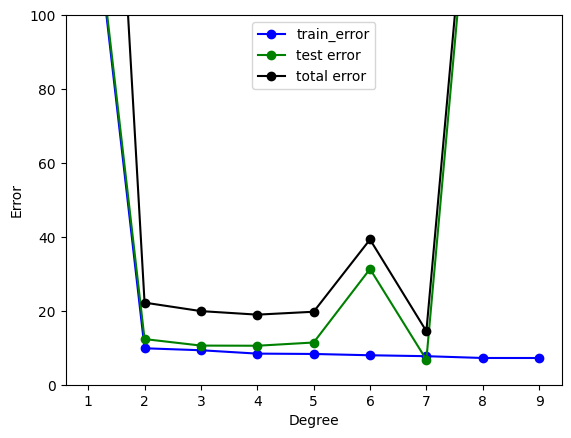

In [23]:
plt.figure()
plt.plot(degrees, train_errors, color="b", marker="o", label="train_error")
plt.plot(degrees, test_errors, color="g", marker="o", label="test error")
plt.plot(degrees, np.array(train_errors)+np.array(test_errors), c="k", marker="o", label="total error")
plt.ylim(0,100) # Limiting the y-axis so that the trend is visible more clearly
plt.xlabel("Degree")
plt.ylabel("Error")
plt.legend()

### And we see the bias-variance tradeoff at play
The train error decreases with increases with degree. The test error first drops and again begins to rise.

## Fitting higher degree polynomials
Let's try increasing the degree further and see if we can find the same trend in the bias-variance tradeoff at higher degrees.

degree = 1, train_r2_score = 0.02937510720510217, test_r2_score = -0.03912798782600069 
		 train_error=143.09841013876851, test_error=144.60468995048183


degree = 6, train_r2_score = 0.945934302821902, test_r2_score = 0.7749158274123696 
		 train_error=7.97086018158074, test_error=31.322635297207633


degree = 11, train_r2_score = 0.9596890706898944, test_r2_score = -130.69674843841744 
		 train_error=5.943006343967035, test_error=18326.87378122359


degree = 16, train_r2_score = 0.9705233251598049, test_r2_score = -595806.9829191852 
		 train_error=4.345721335935984, test_error=82912432.00974917


degree = 21, train_r2_score = 0.9803120925100489, test_r2_score = -169870644.17461637 
		 train_error=2.902571613075734, test_error=23639139995.21386


degree = 26, train_r2_score = 0.9540395009664953, test_r2_score = -3817970890.3505907 
		 train_error=6.775917648207984, test_error=531307503456.6041


degree = 31, train_r2_score = 0.9143166218024132, test_r2_score = -65064947051.42378 
		 

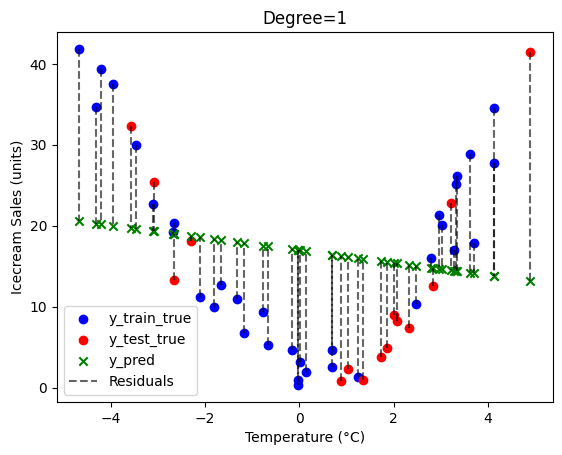

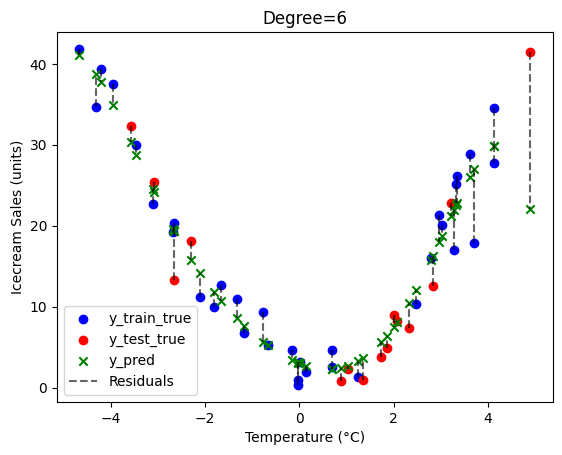

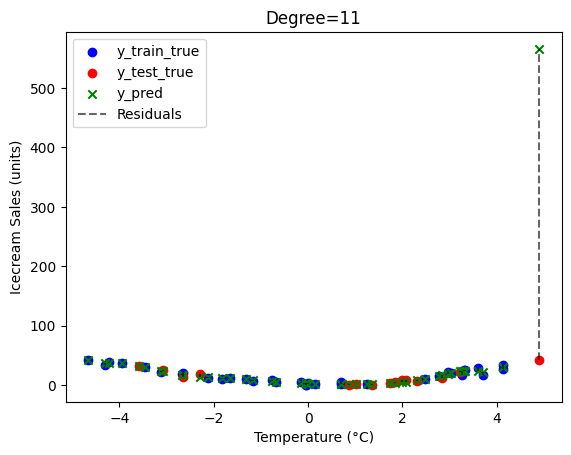

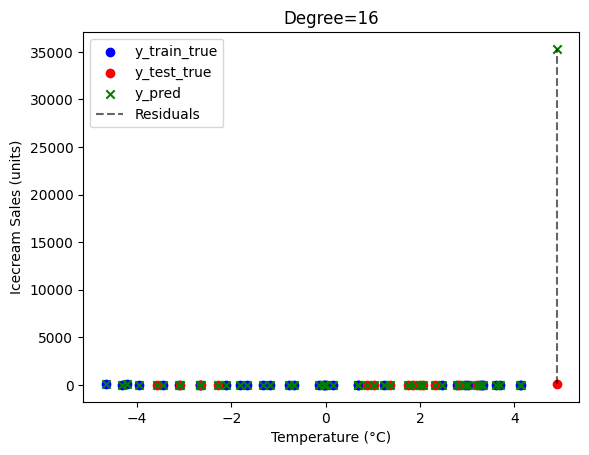

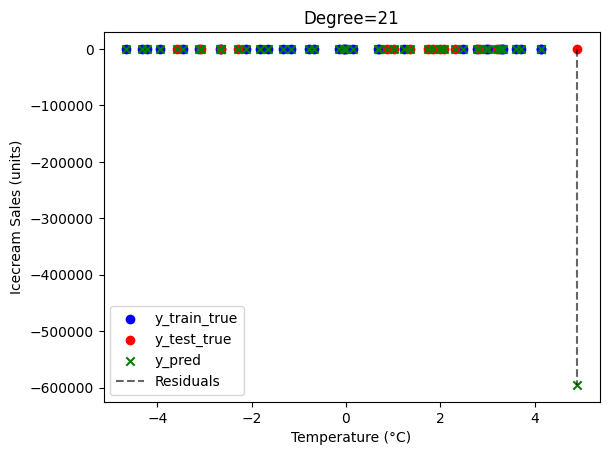

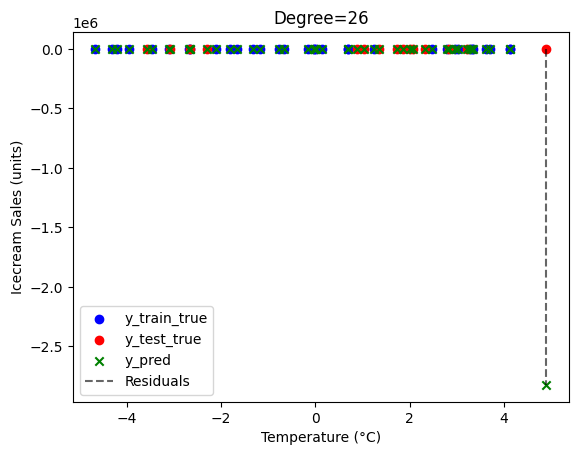

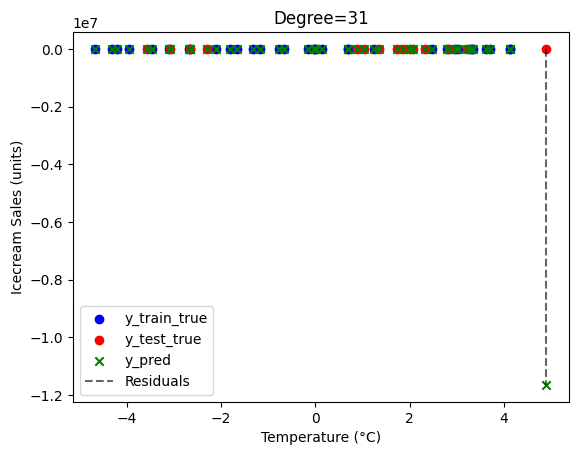

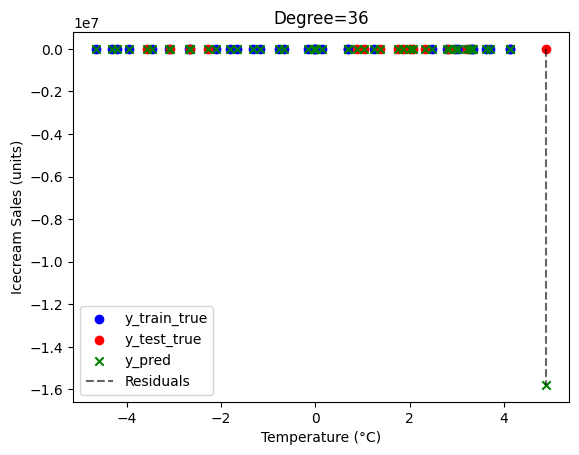

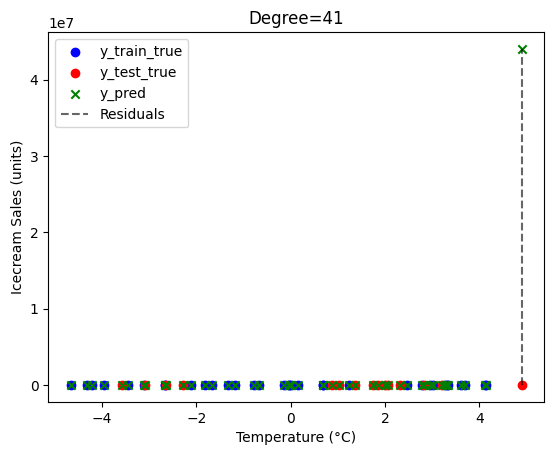

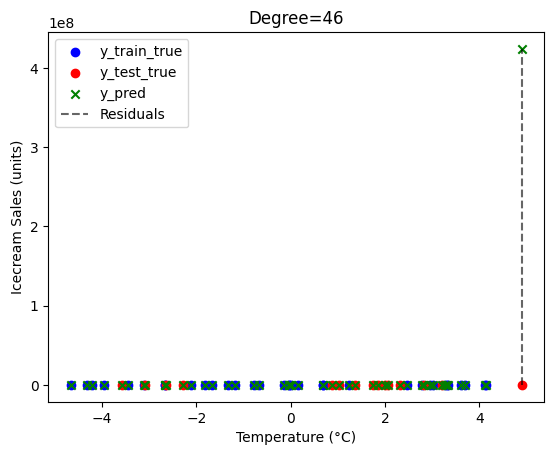

In [25]:
degrees = range(1,50, 5)
train_errors = []
test_errors = []
for degree in degrees:
  if degree>1: # We need to include polynomial features only for models with degree above 1
    poly_features = PolynomialFeatures(degree=degree)
    X_transformed = poly_features.fit_transform(X)

  else: # The features remain as is for the linear model. We are just converting it to a numpy array for consistency since poly_features.fit_transform returns a numpy ndarray.
    # We need to add a column of ones as scaling factors for the intercept parameter, so that the values of Temeperature always appear as the second column following the ones.
    # This step ensures that the parameter corresponding to the second column will always be the linear term in all models we are building.  It helps if we want to compare the parameters across models.
    ones_col = np.ones((len(X), 1))
    X_transformed = np.hstack((ones_col, X.to_numpy()))

  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3, random_state=0)

  model = LinearRegression()
  model.fit(X_train,y_train)
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  y_pred_all = model.predict(X_transformed)
  train_error = mean_squared_error(y_train, y_pred_train)
  train_errors.append(train_error)
  test_error = mean_squared_error(y_test, y_pred_test)
  test_errors.append(test_error)
  print(f"degree = {degree}, train_r2_score = {r2_score(y_train, y_pred_train)}, test_r2_score = {r2_score(y_test, y_pred_test)} \n\t\t train_error={train_error}, test_error={test_error}\n\n")
  plt.figure()
  plt.scatter(X_train[:, 1], y_train[:], color="b", label="y_train_true")
  plt.scatter(X_test[:, 1], y_test[:], color="r", label="y_test_true")
  plt.scatter(X, y_pred_all, color="g", marker="x", label="y_pred")
  plt.vlines(X, y, y_pred_all, color='k', linestyle='--', alpha=0.6, label='Residuals')
  plt.title(f"Degree={degree}")
  plt.xlabel("Temperature (°C)")
  plt.ylabel("Icecream Sales (units)")
  plt.legend()
  # print(train_errors, test_errors)
  # print(r2_score(y_test, y_pred_test))


Now let's plot the train and test errors as a function of degrees

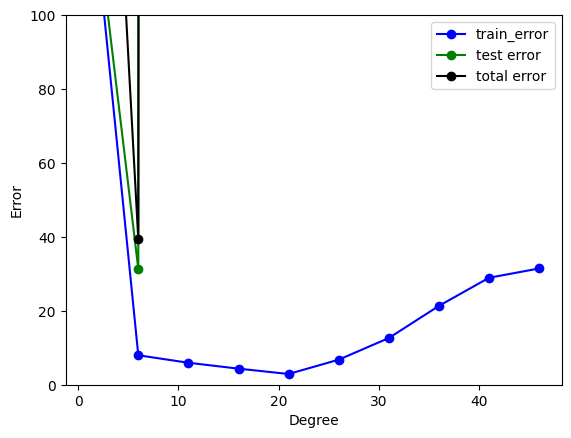

In [26]:
plt.figure()
plt.plot(degrees, train_errors, color="b", marker="o", label="train_error")
plt.plot(degrees, test_errors, color="g", marker="o", label="test error")
plt.plot(degrees, np.array(train_errors)+np.array(test_errors), c="k", marker="o", label="total error")
plt.ylim(0,100) # Limiting the y-axis so that the trend is visible more clearly
plt.xlabel("Degree")
plt.ylabel("Error")
plt.legend()

The train error seems to be increasing! This shouldn't actually happen, because higher degree polynomials should ideally overfit data and keep the train error low.

**So what exactly is happening here?**

We are running into numerical issues because the computer can't handle numbers that span very wide ranges. For example, in the linear model, x ranges between -5 to 5. However, when we add polynomials in the degree 50 model, while the values corresponding to feature x still lie between between -5 to 5, the values corresponding to feature x^50 are scaled to the range of (-5)^50 to (5)^50. These are orders of different, and computers are very bad at handling such large differences.

**So what's the solution?**

Scale the features so that they lie in similar ranges.

In [72]:
X_unscaled = data.iloc[:, :-1]
X = X_unscaled.copy()
print("Before scaling")
print(X_unscaled)
scaler = MinMaxScaler() # You can use alternate scalers that make sense here or just divide the values by 5 so that they can lie in the range -1 to 1
scaler.fit(X_unscaled)
X["Temperature (°C)"] = scaler.transform(X_unscaled)

print("After scaling")
print(X)

y = data.iloc[:, -1]
x_values = pd.DataFrame(data=np.arange(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 0.01), columns=["Temperature (°C)"]) # Just to understand what the model is doing at places where we don't have data. So creating a list of temperature values that span the whole range.

Before scaling
    Temperature (°C)
0          -4.662263
1          -4.316559
2          -4.213985
3          -3.949661
4          -3.578554
5          -3.455712
6          -3.108440
7          -3.081303
8          -2.672461
9          -2.652287
10         -2.651498
11         -2.288264
12         -2.111870
13         -1.818938
14         -1.660348
15         -1.326379
16         -1.173123
17         -0.773330
18         -0.673753
19         -0.149635
20         -0.036156
21         -0.033895
22          0.008608
23          0.149245
24          0.688781
25          0.693599
26          0.874905
27          1.024181
28          1.240712
29          1.359813
30          1.740000
31          1.850552
32          1.999310
33          2.075101
34          2.318591
35          2.471946
36          2.784836
37          2.831760
38          2.959932
39          3.020874
40          3.211366
41          3.270044
42          3.316073
43          3.335932
44          3.610778
45          3.70405

Now let's try running higher degree models on the scaled data

1 143.09841013876851 144.60468995048183
[143.09841013876851] [144.60468995048183]
-0.03912798782600069
6 7.97086018158102 31.322635297184387
[143.09841013876851, 7.97086018158102] [144.60468995048183, 31.322635297184387]
0.7749158274125366
11 5.943006344141387 18326.87380120473
[143.09841013876851, 7.97086018158102, 5.943006344141387] [144.60468995048183, 31.322635297184387, 18326.87380120473]
-130.69674858200173
16 4.345741098887282 82906802.17568514
[143.09841013876851, 7.97086018158102, 5.943006344141387, 4.345741098887282] [144.60468995048183, 31.322635297184387, 18326.87380120473, 82906802.17568514]
-595766.5269827646
21 3.3748871049626503 5257073802.580656
[143.09841013876851, 7.97086018158102, 5.943006344141387, 4.345741098887282, 3.3748871049626503] [144.60468995048183, 31.322635297184387, 18326.87380120473, 82906802.17568514, 5257073802.580656]
-37777283.569394544
26 2.7653805552362796 70769277060.29253
[143.09841013876851, 7.97086018158102, 5.943006344141387, 4.34574109888728

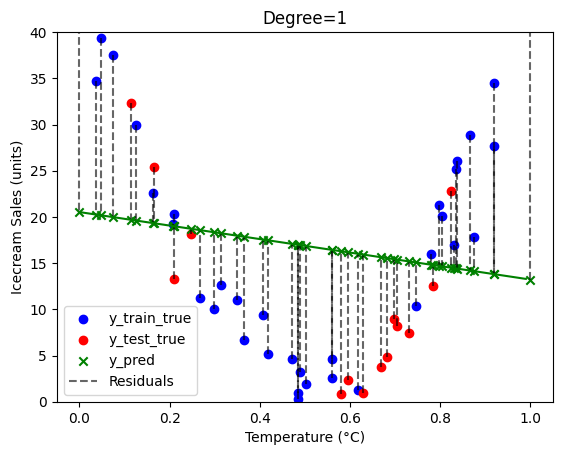

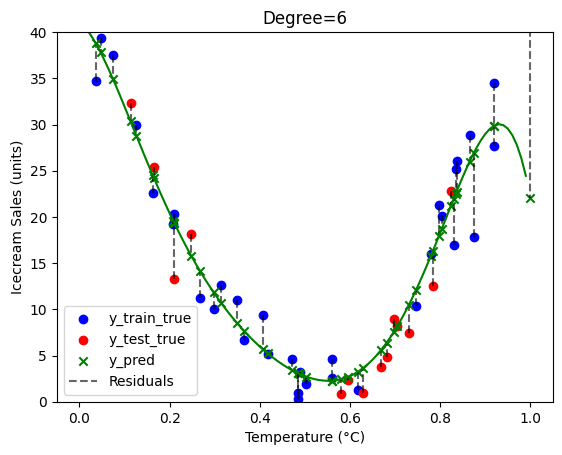

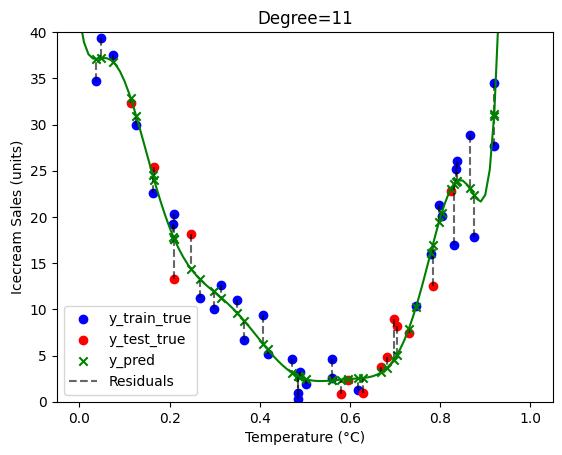

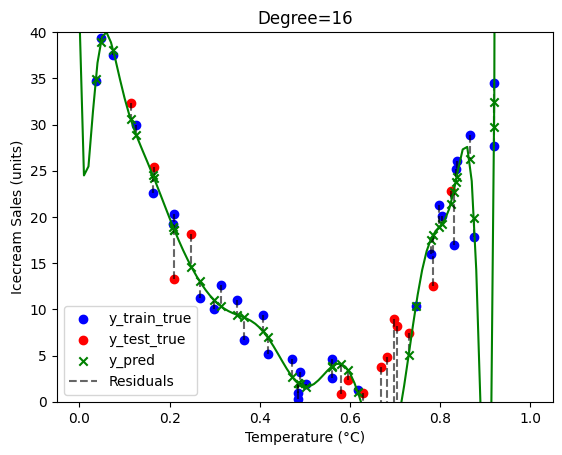

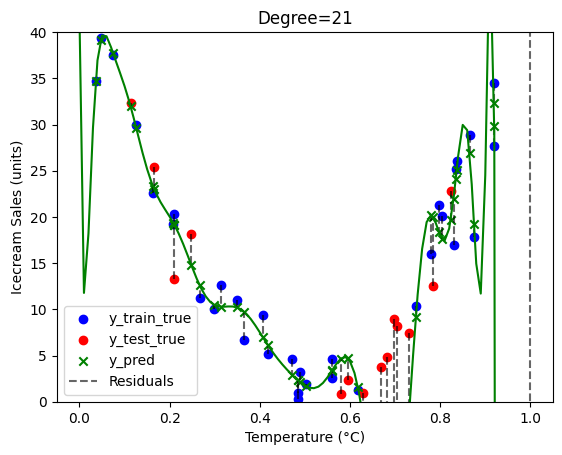

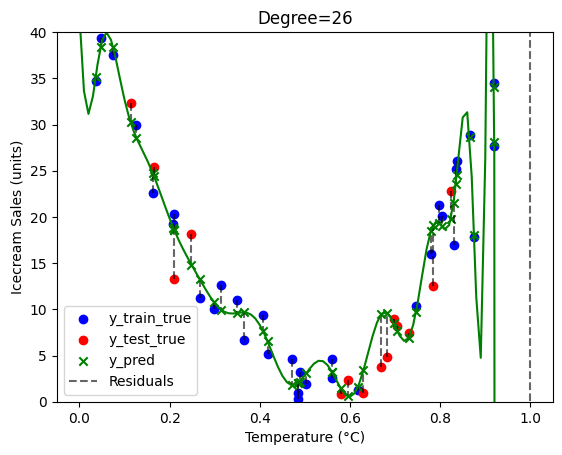

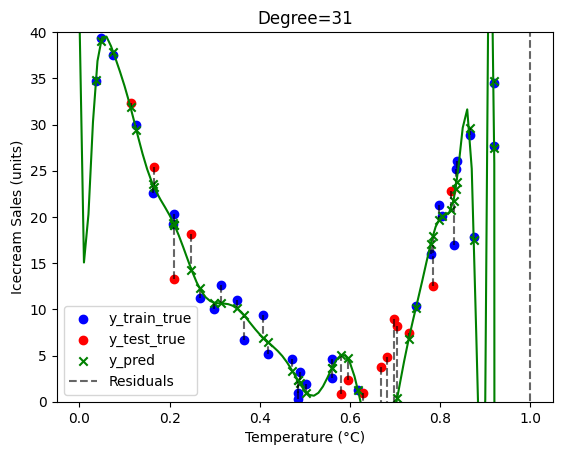

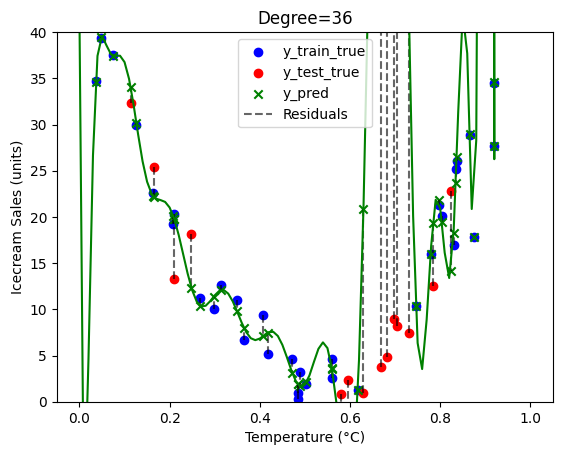

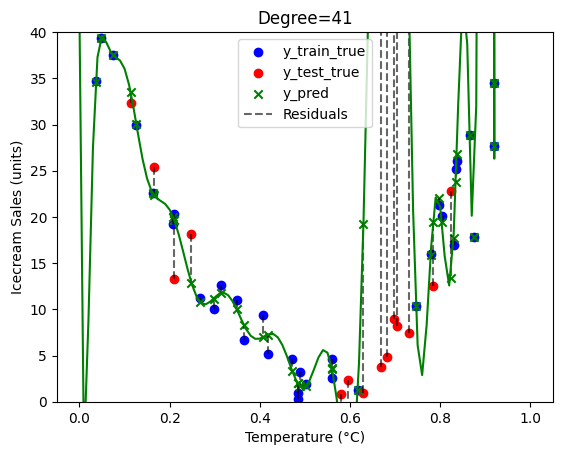

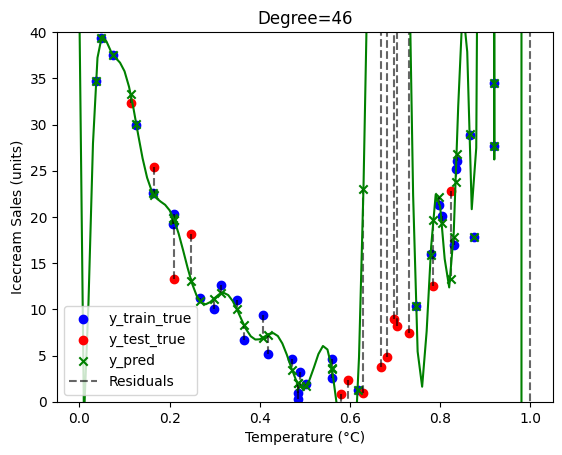

In [75]:
degrees = range(1,50, 5)
train_errors = []
test_errors = []
for degree in degrees:
  if degree>1:
    poly_features = PolynomialFeatures(degree=degree)
    X_transformed = poly_features.fit_transform(X)
    x_values_transformed = poly_features.fit_transform(x_values)

  else:
    ones_col = np.ones((len(X), 1))
    X_transformed = np.hstack((ones_col, X.to_numpy()))
    ones_col_x_values = np.ones((len(x_values), 1))
    x_values_transformed = np.hstack((ones_col_x_values, x_values.to_numpy()))

  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.3, random_state=0)
  model = LinearRegression()
  model.fit(X_train,y_train)

  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  y_pred_all = model.predict(X_transformed)

  y_values_pred = model.predict(x_values_transformed)

  train_error = mean_squared_error(y_train, y_pred_train)
  train_errors.append(train_error)
  test_error = mean_squared_error(y_test, y_pred_test)
  test_errors.append(test_error)

  print(degree, train_error, test_error)

  plt.figure()
  plt.scatter(X_train[:, 1], y_train[:], color="b", label="y_train_true")
  plt.scatter(X_test[:, 1], y_test[:], color="r", label="y_test_true")
  plt.scatter(X, y_pred_all, color="g", marker="x", label="y_pred")
  plt.vlines(X, y, y_pred_all, color='k', linestyle='--', alpha=0.6, label='Residuals')
  plt.plot(x_values, y_values_pred, color="g")
  plt.title(f"Degree={degree}")
  plt.xlabel("Temperature (°C)")
  plt.ylabel("Icecream Sales (units)")
  plt.ylim(0,40)
  plt.legend()

  print(train_errors, test_errors)
  print(r2_score(y_test, y_pred_test))


Notice how the higher degree polynomials generate unnecessary curvatures, which lead to an increase in the test error.

Now let's plot the train and test errors as a function of degrees

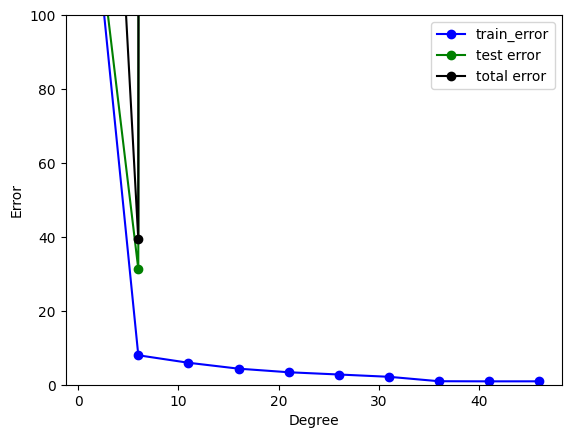

In [76]:
plt.figure()
plt.plot(degrees, train_errors, color="b", marker="o", label="train_error")
plt.plot(degrees, test_errors, color="g", marker="o", label="test error")
plt.plot(degrees, np.array(train_errors)+np.array(test_errors), c="k", marker="o", label="total error")
plt.ylim(0,100) # Limiting the y-axis so that the trend is visible more clearly
plt.xlabel("Degree")
plt.ylabel("Error")
plt.legend()

Finally we get the trend we were expecting. Train error continues to decrease with increase in degree. Test error first decreases and then then begins to rise again due to overfitting.